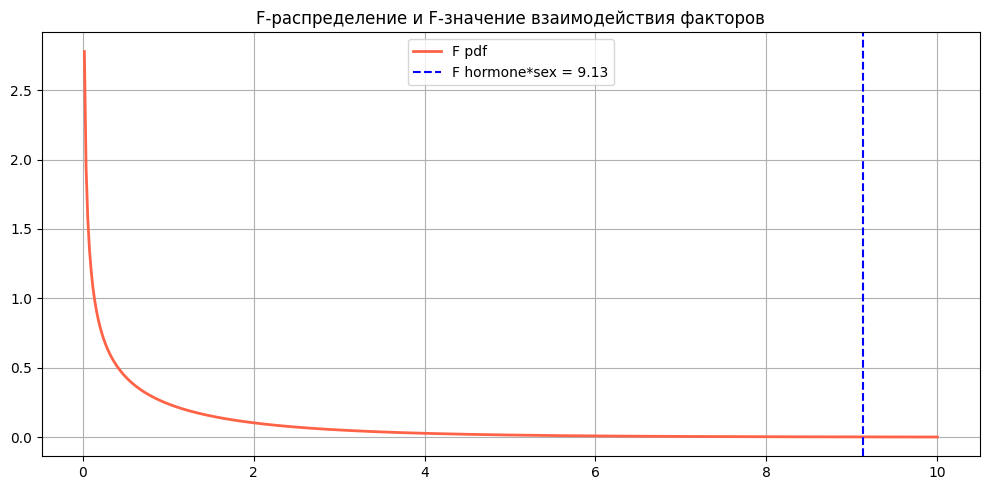

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f
import seaborn as sns
import os
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Загрузка данных
data = pd.read_csv("birds.csv")

# Вычисление общих параметров
df_hormone = len(data.hormone.unique()) - 1
df_sex = len(data.sex.unique()) - 1
df_ab = df_hormone * df_sex
df_each = len(data[(data.sex == 1) & (data.hormone == 1)])
df_e = len(data) - (df_sex + 1) * (df_hormone + 1)

grand_mean = data['var4'].mean()
sst = sum((data.var4 - grand_mean) ** 2)

# Средние по группам
ssb_h0 = data[data.hormone == 0].var4.mean()
ssb_h1 = data[data.hormone == 1].var4.mean()
ssb_h = df_each * ((ssb_h0 - grand_mean) ** 2 + (ssb_h1 - grand_mean) ** 2)

ssb_s0 = data[data.sex == 0].var4.mean()
ssb_s1 = data[data.sex == 1].var4.mean()
ssb_s = df_each * ((ssb_s0 - grand_mean) ** 2 + (ssb_s1 - grand_mean) ** 2)

ssb_hs00 = data[(data.sex == 0) & (data.hormone == 0)].var4.mean()
ssb_hs01 = data[(data.sex == 0) & (data.hormone == 1)].var4.mean()
ssb_hs10 = data[(data.sex == 1) & (data.hormone == 0)].var4.mean()
ssb_hs11 = data[(data.sex == 1) & (data.hormone == 1)].var4.mean()

ssb_hs = df_each * sum([
    (ssb_hs00 - ssb_s0 - ssb_h0 + grand_mean) ** 2,
    (ssb_hs01 - ssb_s0 - ssb_h1 + grand_mean) ** 2,
    (ssb_hs10 - ssb_s1 - ssb_h0 + grand_mean) ** 2,
    (ssb_hs11 - ssb_s1 - ssb_h1 + grand_mean) ** 2
])

# Остаточная сумма квадратов
sse = sst - ssb_h - ssb_s - ssb_hs

# Средние квадраты
ms_h = ssb_h / df_hormone
ms_s = ssb_s / df_sex
ms_hs = ssb_hs / df_ab
ms_e = sse / df_e

# F-значения
f_h = ms_h / ms_e
f_s = ms_s / ms_e
f_hs = ms_hs / ms_e

# P-значения
p_h = f.sf(f_h, df_hormone, df_e)
p_s = f.sf(f_s, df_sex, df_e)
p_hs = f.sf(f_hs, df_ab, df_e)

# Таблица результатов
anova_df = pd.DataFrame({
    'Source': ['Hormone', 'Sex', 'Hormone*Sex', 'Residual'],
    'SS': [ssb_h, ssb_s, ssb_hs, sse],
    'df': [df_hormone, df_sex, df_ab, df_e],
    'MS': [ms_h, ms_s, ms_hs, ms_e],
    'F': [f_h, f_s, f_hs, np.nan],
    'p-value': [p_h, p_s, p_hs, np.nan]
})


# График F-распределения
x = np.linspace(0, 10, 500)
plt.figure(figsize=(10, 5))
plt.plot(x, f.pdf(x, df_ab, df_e), label='F pdf', color='tomato', lw=2)
plt.axvline(x=f_hs, color='blue', linestyle='--', label=f'F hormone*sex = {f_hs:.2f}')
plt.title("F-распределение и F-значение взаимодействия факторов")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

URL = 'https://stepik.org/media/attachments/lesson/9250/birds.csv'
data = pd.read_csv(URL)

formula = 'var4 ~ C(hormone) + C(sex) + C(hormone):C(sex)'
model = ols(formula, data).fit()
aov_table = anova_lm(model, typ=2)
print(aov_table)

                       sum_sq    df         F    PR(>F)
C(hormone)           0.847472   1.0  0.086528  0.769653
C(sex)               0.119762   1.0  0.012228  0.912318
C(hormone):C(sex)   89.483384   1.0  9.136390  0.003682
Residual           587.650394  60.0       NaN       NaN


                   sum_sq  df         F    PR(>F)
hormone          0.847472   1  0.086528  0.769653
sex              0.119762   1  0.012228  0.912318
hormone : sex   89.483384   1   9.13639  0.003682
Residual       587.650394  60       NaN       NaN


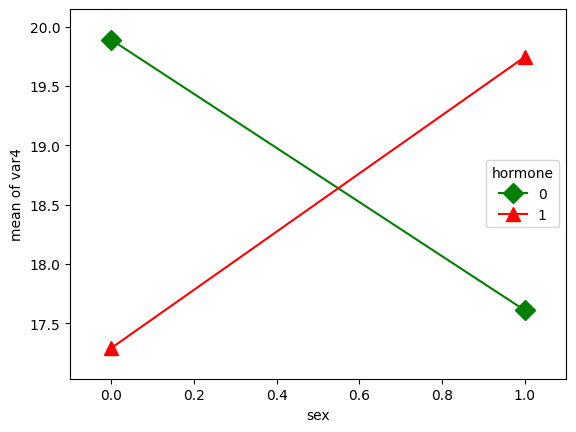